In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\WINDOWS 10\Downloads\global_programming_languages_dataset_2020_2026.csv")
df.head


<bound method NDFrame.head of         language  year                                  creator  \
0         Python  2020                         Guido van Rossum   
1     JavaScript  2020                             Brendan Eich   
2           Java  2020                            James Gosling   
3            SQL  2020  Donald D. Chamberlin & Raymond F. Boyce   
4            C++  2020                        Bjarne Stroustrup   
..           ...   ...                                      ...   
198      Haskell  2026    Simon Peyton Jones et al. (committee)   
199  Objective-C  2026                      Brad Cox & Tom Love   
200       Groovy  2026                           James Strachan   
201      Clojure  2026                              Rich Hickey   
202           F#  2026                     Microsoft (Don Syme)   

     first_release typing_discipline  \
0             1991           Dynamic   
1             1995           Dynamic   
2             1995            Static   
3    

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   language                 203 non-null    str    
 1   year                     203 non-null    int64  
 2   creator                  203 non-null    str    
 3   first_release            203 non-null    int64  
 4   typing_discipline        203 non-null    str    
 5   paradigm                 203 non-null    str    
 6   github_repositories      203 non-null    int64  
 7   stackoverflow_questions  203 non-null    int64  
 8   tiobe_rank               203 non-null    int64  
 9   pypl_rank                203 non-null    int64  
 10  github_stars             203 non-null    int64  
 11  average_salary_usd       203 non-null    float64
 12  learning_difficulty      203 non-null    float64
 13  performance_score        203 non-null    float64
 14  ai_popularity_score      203 non-null

In [3]:
df.columns

Index(['language', 'year', 'creator', 'first_release', 'typing_discipline',
       'paradigm', 'github_repositories', 'stackoverflow_questions',
       'tiobe_rank', 'pypl_rank', 'github_stars', 'average_salary_usd',
       'learning_difficulty', 'performance_score', 'ai_popularity_score',
       'web_development_score', 'data_science_score', 'mobile_score',
       'game_dev_score', 'embedded_score', 'demand_score'],
      dtype='str')

In [4]:
df.isnull().sum()

language                   0
year                       0
creator                    0
first_release              0
typing_discipline          0
paradigm                   0
github_repositories        0
stackoverflow_questions    0
tiobe_rank                 0
pypl_rank                  0
github_stars               0
average_salary_usd         0
learning_difficulty        0
performance_score          0
ai_popularity_score        0
web_development_score      0
data_science_score         0
mobile_score               0
game_dev_score             0
embedded_score             0
demand_score               0
dtype: int64

In [5]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['demand_score'] = pd.to_numeric(df['demand_score'], errors='coerce')

In [6]:
df[['language', 'year', 'demand_score']].dtypes

language            str
year              int64
demand_score    float64
dtype: object

In [7]:
df['year'].min(), df['year'].max()

(np.int64(2020), np.int64(2026))

In [8]:
df['language'].unique()

<StringArray>
[      'Python',   'JavaScript',         'Java',          'SQL',
          'C++',   'TypeScript',           'C#',            'C',
 'Shell (Bash)',          'PHP',           'Go',        'Swift',
         'Ruby',       'Kotlin',            'R',       'MATLAB',
         'Rust',         'Perl',       'VB.NET',        'Scala',
          'Lua',         'Dart',  'Objective-C',       'Groovy',
      'Haskell',       'Elixir',        'Julia',      'Clojure',
           'F#']
Length: 29, dtype: str

In [9]:
df['language'].nunique()

29

In [10]:
yearly_demand = (
    df.groupby(["year", "language"])["demand_score"]
      .mean()
      .reset_index()
)

yearly_demand.head(20)

,year,language,demand_score
0,2020,C,17.22
1,2020,C#,18.62
2,2020,C++,18.78
3,2020,Clojure,15.05
4,2020,Dart,13.81
5,2020,Elixir,11.76
6,2020,F#,17.68
7,2020,Go,24.06
8,2020,Groovy,13.82
9,2020,Haskell,23.34


In [11]:
df["demand_score"].mean()

np.float64(22.688177339901475)

In [12]:
language_demand= df.groupby("language")["demand_score"].mean().sort_values(ascending=False)
print(language_demand)

language
Python          51.127143
JavaScript      33.620000
TypeScript      32.335714
Rust            31.391429
R               29.862857
Go              29.770000
Julia           28.138571
Java            27.015714
Swift           26.502857
Scala           25.220000
Kotlin          23.467143
C++             22.680000
C#              21.324286
MATLAB          20.341429
Elixir          19.400000
C               19.278571
Haskell         19.102857
Clojure         18.870000
SQL             18.778571
Dart            18.454286
F#              18.331429
Objective-C     17.810000
Groovy          17.507143
Ruby            16.747143
Perl            16.018571
Shell (Bash)    14.785714
VB.NET          14.121429
PHP             13.068571
Lua             12.885714
Name: demand_score, dtype: float64


In [13]:
year_language_demand=df.groupby(["year","language"])["demand_score"].mean().reset_index()
year_language_demand.head(10)

,year,language,demand_score
0,2020,C,17.22
1,2020,C#,18.62
2,2020,C++,18.78
3,2020,Clojure,15.05
4,2020,Dart,13.81
5,2020,Elixir,11.76
6,2020,F#,17.68
7,2020,Go,24.06
8,2020,Groovy,13.82
9,2020,Haskell,23.34


In [14]:
pivot_data = year_language_demand.pivot(
    index="year",
    columns="language",
    values="demand_score"
)

pivot_data

language,C,C#,C++,Clojure,Dart,Elixir,F#,Go,Groovy,Haskell,...,Python,R,Ruby,Rust,SQL,Scala,Shell (Bash),Swift,TypeScript,VB.NET
year,,,,,,,,,,,,,,,,,,,,,
2020,17.22,18.62,18.78,15.05,13.81,11.76,17.68,24.06,13.82,23.34,...,49.56,26.18,15.94,29.49,12.80,23.30,17.25,24.79,29.70,12.95
2021,20.87,17.77,21.19,15.35,15.15,19.26,20.05,24.15,18.01,17.39,...,49.50,20.04,18.05,26.31,17.44,19.06,12.67,21.79,27.66,14.12
2022,12.89,15.39,21.90,20.15,18.86,22.87,19.53,27.03,18.69,17.93,...,51.75,34.92,10.16,29.08,16.02,24.96,14.77,22.56,31.67,11.83
2023,18.80,24.89,25.33,23.52,14.41,18.39,15.83,30.21,17.96,20.11,...,49.96,31.22,15.47,30.94,19.58,27.75,13.36,24.11,32.78,10.40
2024,19.90,23.99,22.82,22.72,22.98,18.64,19.35,31.55,19.20,18.79,...,51.91,29.50,18.93,32.56,15.88,29.82,13.02,26.82,37.27,11.90
2025,20.58,24.90,24.43,20.43,24.75,20.38,19.45,36.15,16.37,20.28,...,52.44,31.52,17.91,33.10,21.91,24.96,12.61,30.46,38.09,19.83
2026,24.69,23.71,24.31,14.87,19.22,24.50,16.43,35.24,18.50,15.88,...,52.77,35.66,20.77,38.26,27.82,26.69,19.82,34.99,29.18,17.82


In [15]:
top_languages=(
    df.groupby("language")["demand_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_languages

language
Python        51.127143
JavaScript    33.620000
TypeScript    32.335714
Rust          31.391429
R             29.862857
Go            29.770000
Julia         28.138571
Java          27.015714
Swift         26.502857
Scala         25.220000
Name: demand_score, dtype: float64

In [16]:
top_10_names = top_languages.index

trend_data = pivot_data[top_10_names]

trend_data

language,Python,JavaScript,TypeScript,Rust,R,Go,Julia,Java,Swift,Scala
year,,,,,,,,,,
2020,49.56,30.48,29.70,29.49,26.18,24.06,21.64,28.98,24.79,23.30
2021,49.50,30.80,27.66,26.31,20.04,24.15,30.88,26.52,21.79,19.06
2022,51.75,38.50,31.67,29.08,34.92,27.03,26.56,23.39,22.56,24.96
2023,49.96,30.42,32.78,30.94,31.22,30.21,31.84,32.06,24.11,27.75
2024,51.91,35.85,37.27,32.56,29.50,31.55,29.19,25.42,26.82,29.82
2025,52.44,35.23,38.09,33.10,31.52,36.15,25.94,24.31,30.46,24.96
2026,52.77,34.06,29.18,38.26,35.66,35.24,30.92,28.43,34.99,26.69


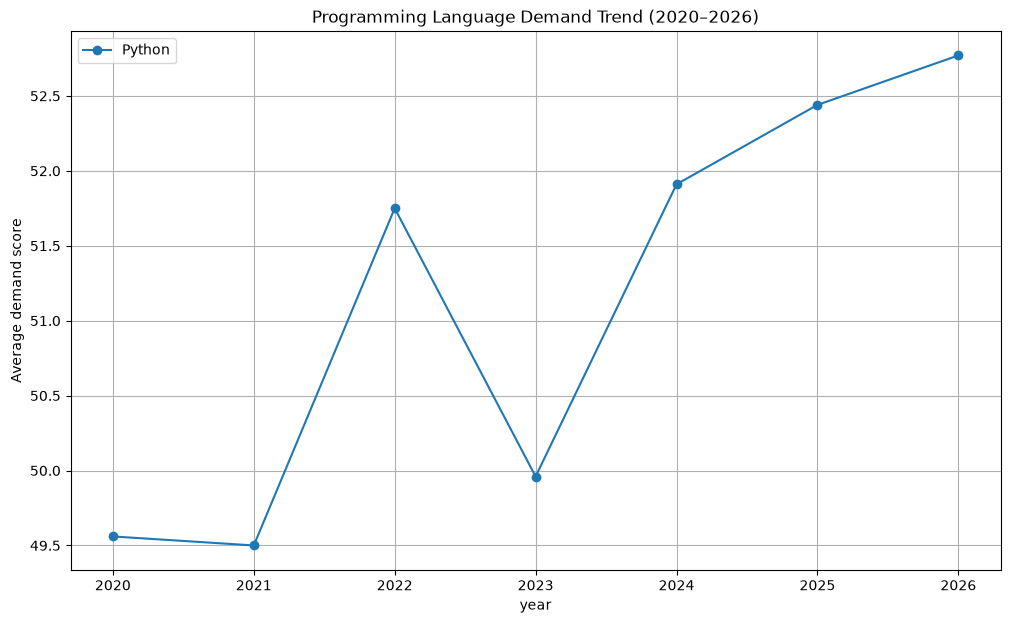

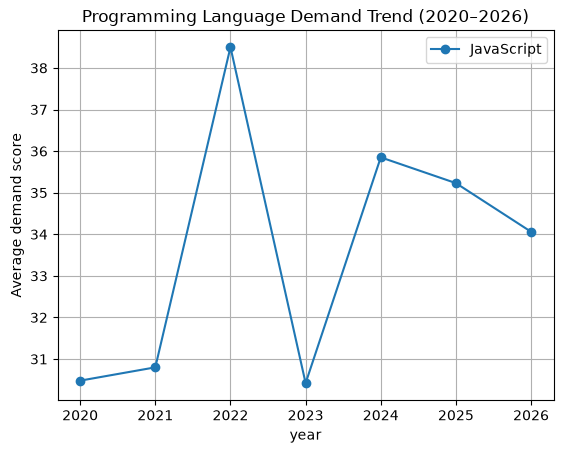

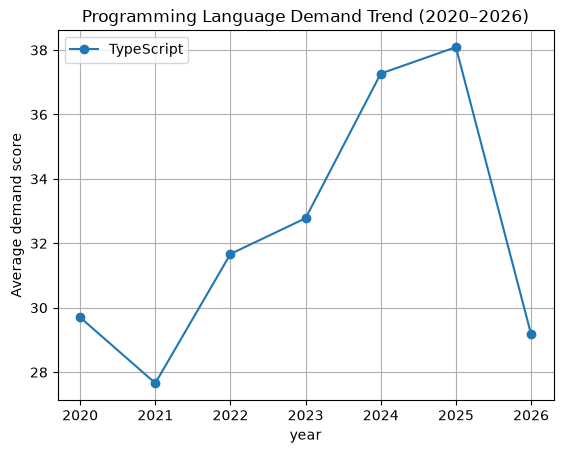

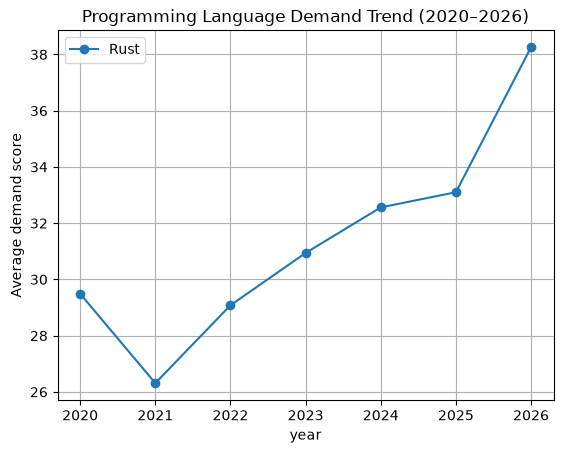

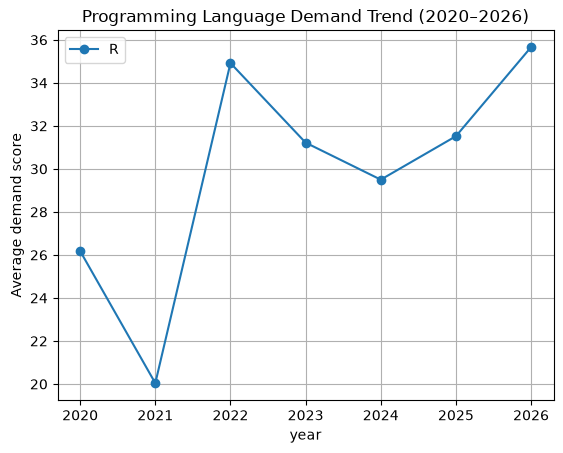

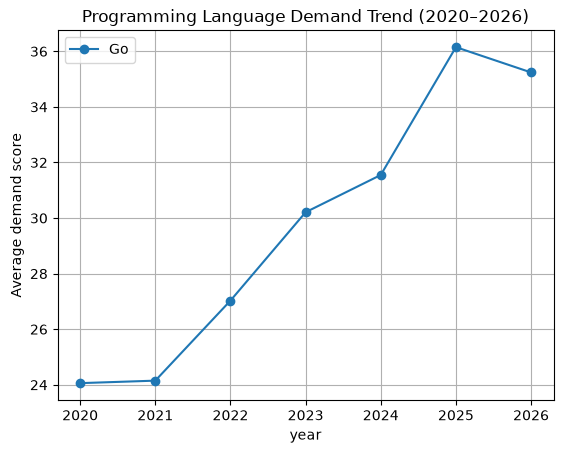

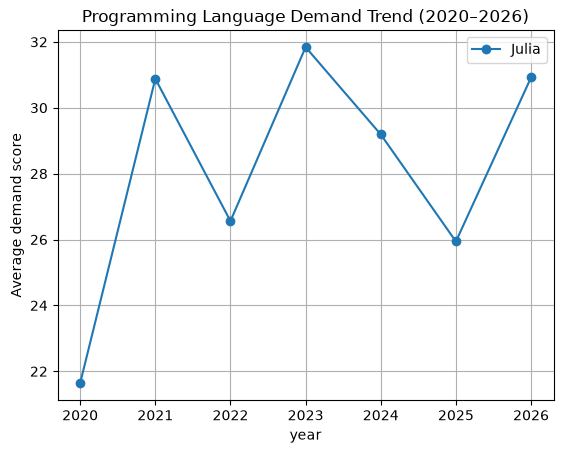

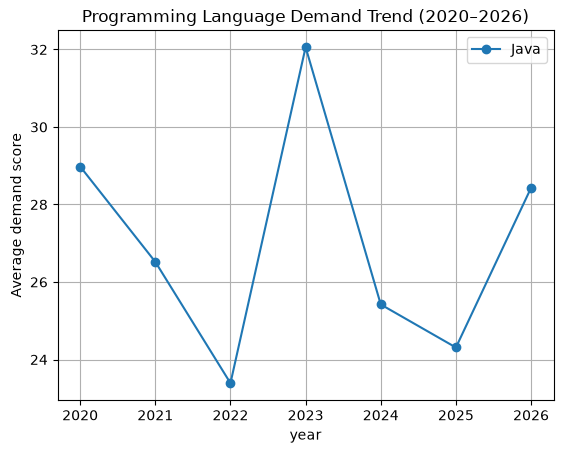

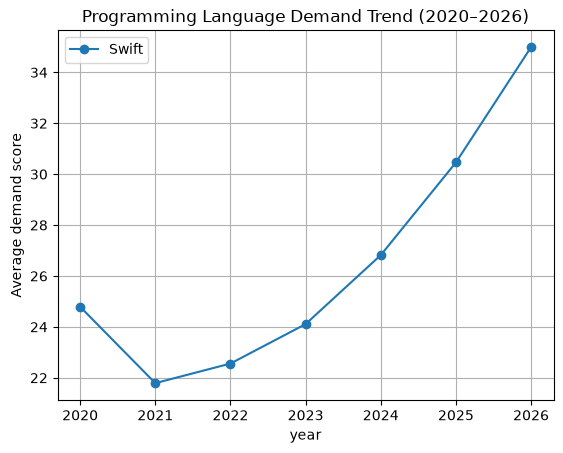

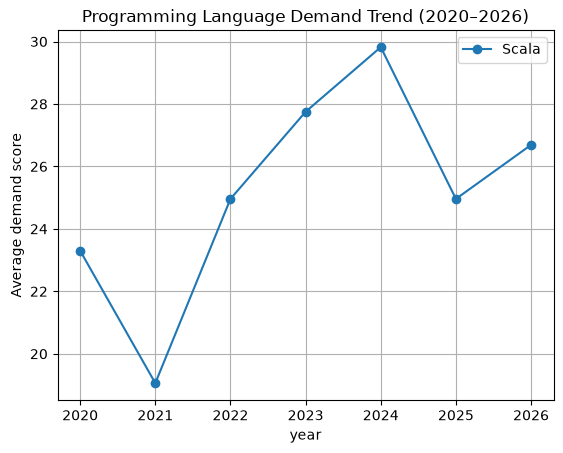

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,7))
for language in trend_data.columns:
    plt.plot(
        trend_data.index,
        trend_data[language],
        marker='o',
         label=language)
    plt.xlabel("year")
    plt.ylabel("Average demand score")
    plt.title("Programming Language Demand Trend (2020–2026)")
    plt.legend()
    plt.grid(True)
    plt.show()

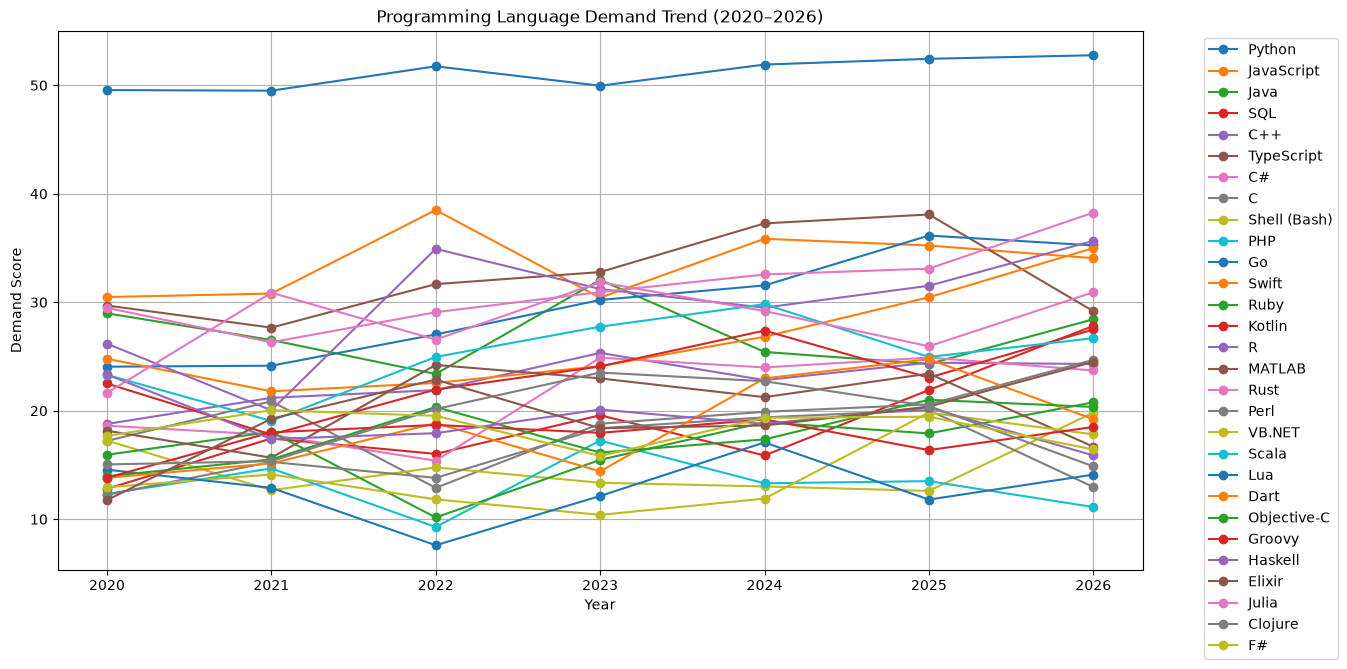

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for language in df["language"].unique():
    data = df[df["language"] == language]

    plt.plot(
        data["year"],
        data["demand_score"],
        marker="o",
        label=language
    )

plt.xlabel("Year")
plt.ylabel("Demand Score")
plt.title("Programming Language Demand Trend (2020–2026)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [19]:
growth = (
    df.groupby("language")
      .agg(
          start_demand=("demand_score", "first"),
          end_demand=("demand_score", "last")
      )
)

growth["absolute_growth"] = (
    growth["end_demand"] - growth["start_demand"]
)

growth = growth.sort_values(
    "absolute_growth",
    ascending=False
)

growth.head(15)

,start_demand,end_demand,absolute_growth
language,,,
SQL,12.80,27.82,15.02
Elixir,11.76,24.50,12.74
Go,24.06,35.24,11.18
Swift,24.79,34.99,10.20
R,26.18,35.66,9.48
Julia,21.64,30.92,9.28
Rust,29.49,38.26,8.77
C,17.22,24.69,7.47
Objective-C,13.96,20.35,6.39


In [20]:
start = df[df["year"] == 2020][["language", "demand_score"]]
start = start.rename(columns={"demand_score": "demand_2020"})

end = df[df["year"] == 2026][["language", "demand_score"]]
end = end.rename(columns={"demand_score": "demand_2026"})

growth = start.merge(end, on="language")

growth["growth"] = (
    growth["demand_2026"] - growth["demand_2020"]
)

growth = growth.sort_values(
    "growth",
    ascending=False
)

growth.head(20)

,language,demand_2020,demand_2026,growth
3,SQL,12.80,27.82,15.02
25,Elixir,11.76,24.50,12.74
10,Go,24.06,35.24,11.18
11,Swift,24.79,34.99,10.20
14,R,26.18,35.66,9.48
26,Julia,21.64,30.92,9.28
16,Rust,29.49,38.26,8.77
7,C,17.22,24.69,7.47
22,Objective-C,13.96,20.35,6.39
4,C++,18.78,24.31,5.53


In [21]:
from sklearn.linear_model import LinearRegression

results = []

for language in df["language"].unique():
    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    results.append({
        "language": language,
        "slope": model.coef_[0]
    })

slope_df = pd.DataFrame(results)

slope_df = slope_df.sort_values(
    "slope",
    ascending=False
)

slope_df.head(10)

,language,slope
10,Go,2.216429
3,SQL,1.923571
11,Swift,1.864286
14,R,1.642143
16,Rust,1.548929
21,Dart,1.412500
6,C#,1.361786
25,Elixir,1.293929
13,Kotlin,1.102857
7,C,1.030000


“Python currently has the highest average demand in this dataset, while Go, SQL and Swift show stronger historical growth trends.”

In [22]:
languages = ["Python", "Go", "SQL", "JavaScript", "Rust"]

forecast_results = []

for language in languages:
    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    prediction_2027 = model.predict([[2027]])[0]

    forecast_results.append({
        "language": language,
        "current_2026": y[temp["year"] == 2026].iloc[0],
        "predicted_2027": prediction_2027
    })

forecast_df = pd.DataFrame(forecast_results)

forecast_df.sort_values(
    "predicted_2027",
    ascending=False
)

C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not

,language,current_2026,predicted_2027
0,Python,52.77,53.365714
1,Go,35.24,38.635714
4,Rust,38.26,37.587143
3,JavaScript,34.06,36.041429
2,SQL,27.82,26.472857


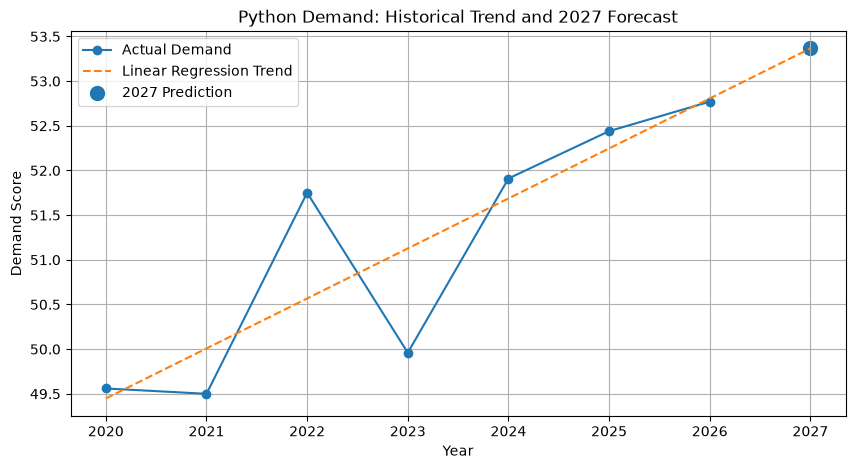

In [23]:
python_data = df[df["language"] == "Python"].copy()

X = python_data[["year"]]
y = python_data["demand_score"]

model = LinearRegression()
model.fit(X, y)

years = list(range(2020, 2028))

predictions = model.predict(
    pd.DataFrame({"year": years})
)

plt.figure(figsize=(10, 5))

plt.plot(
    python_data["year"],
    python_data["demand_score"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    years,
    predictions,
    linestyle="--",
    label="Linear Regression Trend"
)

plt.scatter(
    2027,
    predictions[-1],
    s=100,
    label="2027 Prediction"
)

plt.xlabel("Year")
plt.ylabel("Demand Score")
plt.title("Python Demand: Historical Trend and 2027 Forecast")
plt.legend()
plt.grid(True)

plt.show()

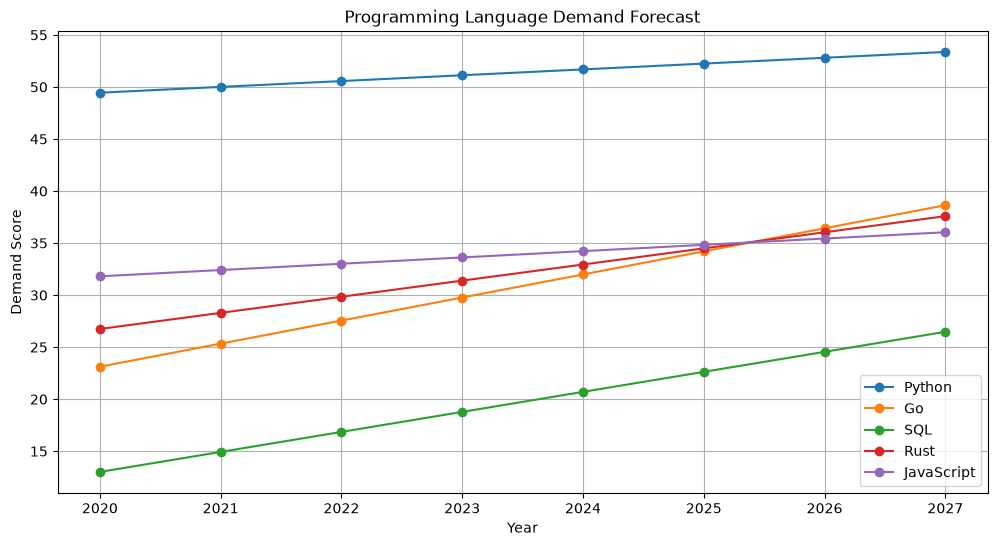

In [24]:
languages = ["Python", "Go", "SQL", "Rust", "JavaScript"]

plt.figure(figsize=(12, 6))

for language in languages:
    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    years = list(range(2020, 2028))
    predictions = model.predict(
        pd.DataFrame({"year": years})
    )

    plt.plot(
        years,
        predictions,
        marker="o",
        label=language
    )

plt.xlabel("Year")
plt.ylabel("Demand Score")
plt.title("Programming Language Demand Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
future = growth.copy()

future["future_potential"] = (
    future["demand_2026"] * 0.6
    + future["growth"] * 0.4
)

future = future.sort_values(
    "future_potential",
    ascending=False
)

future.head(10)

,language,demand_2020,demand_2026,growth,future_potential
0,Python,49.56,52.77,3.21,32.946
16,Rust,29.49,38.26,8.77,26.464
10,Go,24.06,35.24,11.18,25.616
14,R,26.18,35.66,9.48,25.188
11,Swift,24.79,34.99,10.20,25.074
3,SQL,12.80,27.82,15.02,22.700
26,Julia,21.64,30.92,9.28,22.264
1,JavaScript,30.48,34.06,3.58,21.868
25,Elixir,11.76,24.50,12.74,19.796
13,Kotlin,22.51,27.49,4.98,18.486


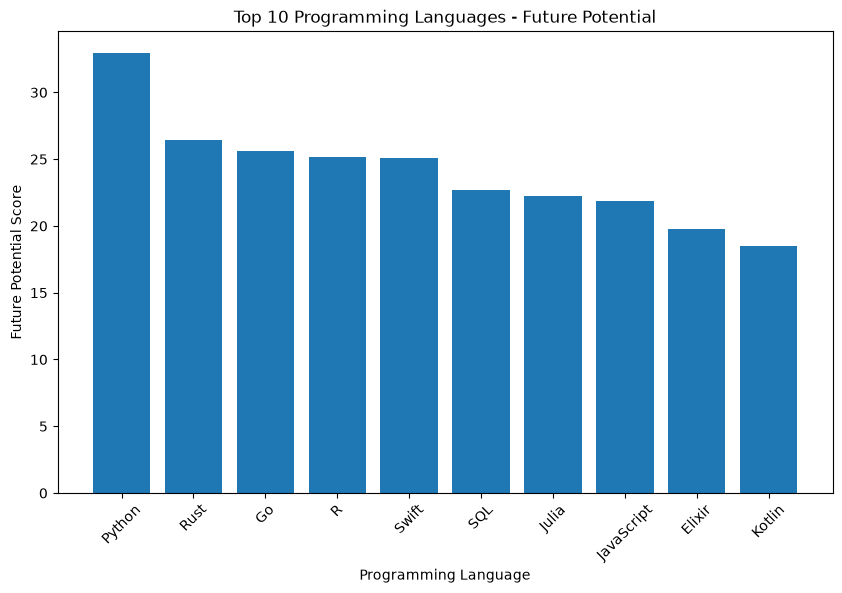

In [26]:
import matplotlib.pyplot as plt

top_future = future.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_future["language"],
    top_future["future_potential"]
)

plt.title("Top 10 Programming Languages - Future Potential")
plt.xlabel("Programming Language")
plt.ylabel("Future Potential Score")
plt.xticks(rotation=45)

plt.show()

"A language with high current demand and strong growth can have greater future potential than a language that is growing rapidly but currently has lower demand."

In [27]:
final_ranking = (
    future[["language", "demand_2026", "growth", "future_potential"]]
    .sort_values("future_potential", ascending=False)
    .reset_index(drop=True)
)

final_ranking.index = final_ranking.index + 1

final_ranking

,language,demand_2026,growth,future_potential
1,Python,52.77,3.21,32.946
2,Rust,38.26,8.77,26.464
3,Go,35.24,11.18,25.616
4,R,35.66,9.48,25.188
5,Swift,34.99,10.20,25.074
6,SQL,27.82,15.02,22.700
7,Julia,30.92,9.28,22.264
8,JavaScript,34.06,3.58,21.868
9,Elixir,24.50,12.74,19.796
10,Kotlin,27.49,4.98,18.486


"The ranking is an analytical estimate based on historical demand and growth, not a guaranteed prediction of the future."

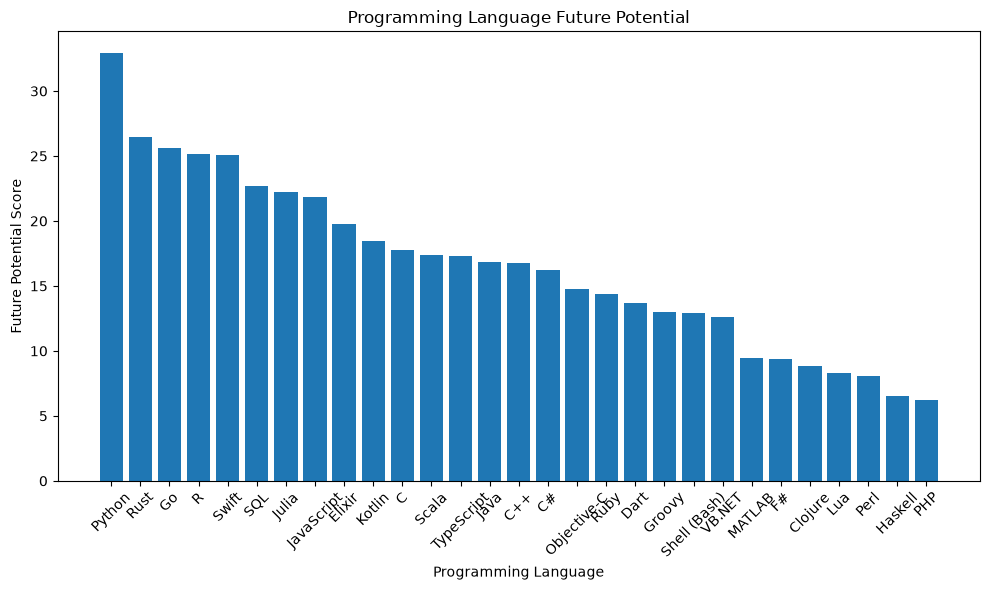

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_ranking["language"],
    final_ranking["future_potential"]
)

plt.title("Programming Language Future Potential")
plt.xlabel("Programming Language")
plt.ylabel("Future Potential Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"Python currently has the strongest overall position, while languages like Go and Rust show stronger growth potential."

In [29]:
print("KEY INSIGHTS")
print("-" * 40)

print("1. Python has the highest overall demand and future potential.")
print("2. Go and Rust show strong growth compared to many other languages.")
print("3. SQL has strong growth, showing the continued importance of data.")
print("4. Some languages have high current demand but slower growth.")
print("5. Future potential depends on both current demand and growth.")

KEY INSIGHTS
----------------------------------------
1. Python has the highest overall demand and future potential.
2. Go and Rust show strong growth compared to many other languages.
3. SQL has strong growth, showing the continued importance of data.
4. Some languages have high current demand but slower growth.
5. Future potential depends on both current demand and growth.


In [30]:
future_years = np.arange(2027, 2037).reshape(-1, 1)

ten_year_forecast = []

for language in languages:

    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(future_years)

    for year, prediction in zip(range(2027, 2037), predictions):
        ten_year_forecast.append({
            "language": language,
            "year": year,
            "predicted_demand": prediction
        })

ten_year_df = pd.DataFrame(ten_year_forecast)

ten_year_df.head(20)

C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\WINDOWS 10\PycharmProjects\kaggle\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not

,language,year,predicted_demand
0,Python,2027,53.365714
1,Python,2028,53.925357
2,Python,2029,54.485000
3,Python,2030,55.044643
4,Python,2031,55.604286
5,Python,2032,56.163929
6,Python,2033,56.723571
7,Python,2034,57.283214
8,Python,2035,57.842857
9,Python,2036,58.402500


"I initially used Linear Regression as a baseline forecasting model, then evaluated whether a time-series approach provided a better representation of the historical trend."

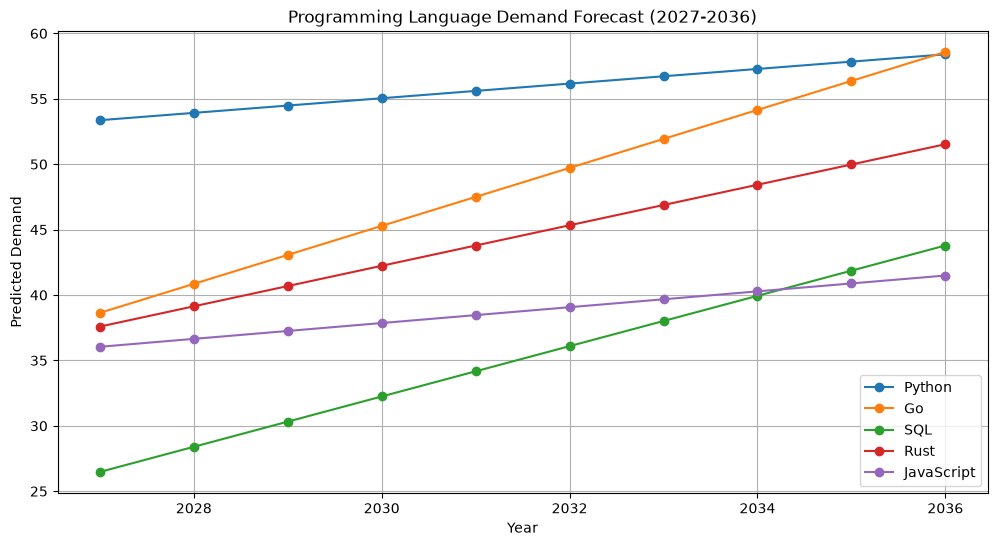

In [31]:
plt.figure(figsize=(12, 6))

for language in ten_year_df["language"].unique():
    temp = ten_year_df[ten_year_df["language"] == language]

    plt.plot(
        temp["year"],
        temp["predicted_demand"],
        marker="o",
        label=language
    )

plt.title("Programming Language Demand Forecast (2027-2036)")
plt.xlabel("Year")
plt.ylabel("Predicted Demand")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
forecast_df.columns

Index(['language', 'current_2026', 'predicted_2027'], dtype='str')

In [33]:
forecast_10_years = []

for language in languages:

    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    for year in range(2027, 2037):

        future_X = pd.DataFrame({"year": [year]})

        prediction = model.predict(future_X)[0]

        forecast_10_years.append({
            "language": language,
            "year": year,
            "predicted_demand": prediction
        })

forecast_10_years = pd.DataFrame(forecast_10_years)

forecast_10_years.head(20)

,language,year,predicted_demand
0,Python,2027,53.365714
1,Python,2028,53.925357
2,Python,2029,54.485000
3,Python,2030,55.044643
4,Python,2031,55.604286
5,Python,2032,56.163929
6,Python,2033,56.723571
7,Python,2034,57.283214
8,Python,2035,57.842857
9,Python,2036,58.402500


In [34]:
forecast_10_years.columns

Index(['language', 'year', 'predicted_demand'], dtype='str')

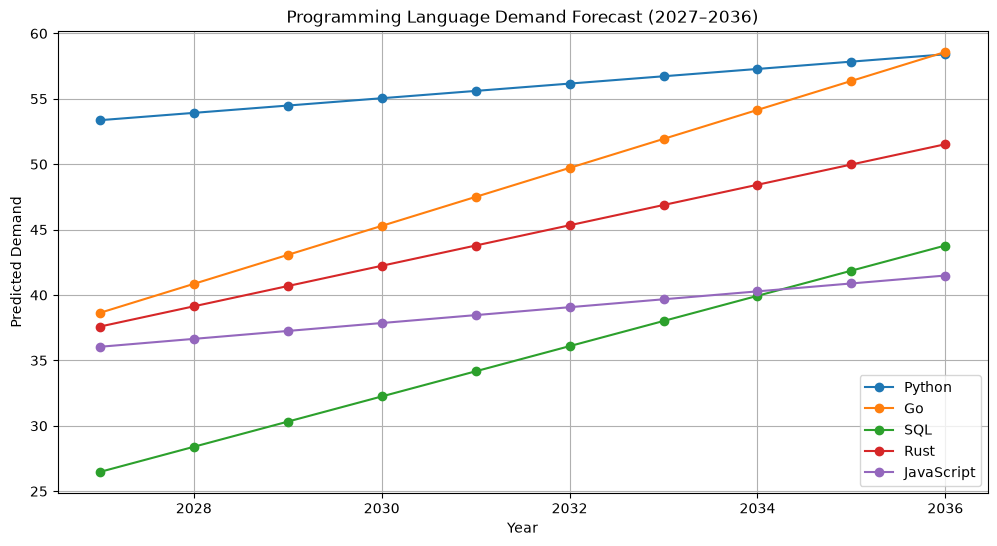

In [35]:
plt.figure(figsize=(12, 6))

for language in languages:
    temp = forecast_10_years[
        forecast_10_years["language"] == language
    ]

    plt.plot(
        temp["year"],
        temp["predicted_demand"],
        marker="o",
        label=language
    )

plt.title("Programming Language Demand Forecast (2027–2036)")
plt.xlabel("Year")
plt.ylabel("Predicted Demand")
plt.legend()
plt.grid(True)

plt.show()


“According to the model, Python remains the highest-demand language throughout most of the forecast period, while Go shows a stronger growth trend and is predicted to approach Python by 2036.”

In [36]:
from sklearn.metrics import mean_absolute_error, r2_score

python_data = df[df["language"] == "Python"]

X = python_data[["year"]]
y = python_data["demand_score"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.4888775510204754
R² Score: 0.7376144501585724


"The Linear Regression model achieved an MAE of approximately 0.49, meaning its predictions differ from the actual demand score by about 0.49 points on average. The R² score is approximately 0.74, indicating that the model explains around 74% of the variation in the demand score."

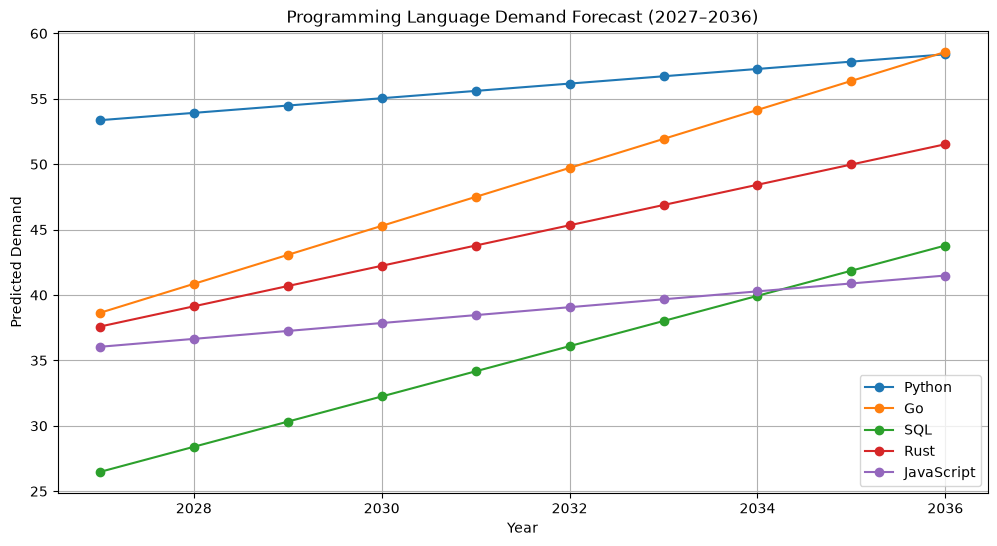

In [37]:
plt.figure(figsize=(12, 6))

for language in languages:
    temp = forecast_10_years[
        forecast_10_years["language"] == language
    ]

    plt.plot(
        temp["year"],
        temp["predicted_demand"],
        marker="o",
        label=language
    )

plt.title("Programming Language Demand Forecast (2027–2036)")
plt.xlabel("Year")
plt.ylabel("Predicted Demand")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
forecast_2036 = forecast_10_years[
    forecast_10_years["year"] == 2036
].sort_values(
    "predicted_demand",
    ascending=False
)

forecast_2036

,language,year,predicted_demand
19,Go,2036,58.583571
9,Python,2036,58.402500
39,Rust,2036,51.527500
29,SQL,2036,43.785000
49,JavaScript,2036,41.489643


In [39]:
current_2026 = df[df["year"] == 2026][
    ["language", "demand_score"]
].rename(columns={"demand_score": "demand_2026"})

future_2036 = forecast_10_years[
    forecast_10_years["year"] == 2036
][
    ["language", "predicted_demand"]
].rename(columns={"predicted_demand": "demand_2036"})

growth_df = current_2026.merge(
    future_2036,
    on="language"
)

growth_df

,language,demand_2026,demand_2036
0,Python,52.77,58.402500
1,JavaScript,34.06,41.489643
2,SQL,27.82,43.785000
3,Go,35.24,58.583571
4,Rust,38.26,51.527500


In [40]:
growth_df["growth_percent"] = (
    (growth_df["demand_2036"] - growth_df["demand_2026"])
    / growth_df["demand_2026"]
) * 100

growth_df.sort_values(
    "growth_percent",
    ascending=False
)

,language,demand_2026,demand_2036,growth_percent
3,Go,35.24,58.583571,66.241690
2,SQL,27.82,43.785000,57.386772
4,Rust,38.26,51.527500,34.677209
1,JavaScript,34.06,41.489643,21.813397
0,Python,52.77,58.402500,10.673678


Python is currently the strongest language in the dataset, but the model forecasts substantially faster relative growth for Go, SQL, and Rust through 2036.

“According to our historical trend and Linear Regression forecast, Python remains the highest-demand language in the current dataset. However, its predicted relative growth from 2026 to 2036 is only about 10.67%, whereas Go shows approximately 66.24% growth, followed by SQL at 57.39% and Rust at 34.68%. Therefore, our model suggests that future demand may become more distributed rather than being dominated by Python alone.”

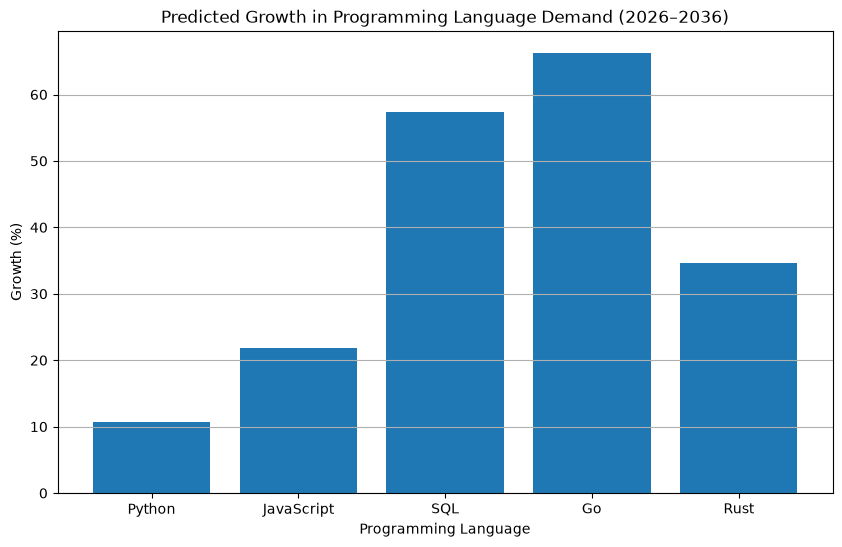

In [41]:
plt.figure(figsize=(10, 6))

plt.bar(
    growth_df["language"],
    growth_df["growth_percent"]
)

plt.title("Predicted Growth in Programming Language Demand (2026–2036)")
plt.xlabel("Programming Language")
plt.ylabel("Growth (%)")

plt.grid(axis="y")
plt.show()

In [42]:
best_language = growth_df.loc[
    growth_df["growth_percent"].idxmax()
]

print("Fastest Growing Programming Language:")
print(best_language)

Fastest Growing Programming Language:
language                 Go
demand_2026           35.24
demand_2036       58.583571
growth_percent     66.24169
Name: 3, dtype: object


In [43]:
growth_df["absolute_growth"] = (
    growth_df["demand_2036"] - growth_df["demand_2026"]
)

growth_df[[
    "language",
    "demand_2026",
    "demand_2036",
    "absolute_growth"
]]

,language,demand_2026,demand_2036,absolute_growth
0,Python,52.77,58.402500,5.632500
1,JavaScript,34.06,41.489643,7.429643
2,SQL,27.82,43.785000,15.965000
3,Go,35.24,58.583571,23.343571
4,Rust,38.26,51.527500,13.267500


In [44]:
actual_vs_predicted = []

for language in languages:

    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    for actual, predicted in zip(y, predictions):
        actual_vs_predicted.append({
            "year":year,
            "language": language,
            "actual": actual,
            "predicted": predicted
        })

actual_vs_predicted = pd.DataFrame(actual_vs_predicted)

actual_vs_predicted.head(10)

,year,language,actual,predicted
0,2036,Python,49.56,49.448214
1,2036,Python,49.50,50.007857
2,2036,Python,51.75,50.567500
3,2036,Python,49.96,51.127143
4,2036,Python,51.91,51.686786
5,2036,Python,52.44,52.246429
6,2036,Python,52.77,52.806071
7,2036,Go,24.06,23.120714
8,2036,Go,24.15,25.337143
9,2036,Go,27.03,27.553571


In [45]:
actual_vs_predicted = []

for language in languages:

    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    for actual, predicted in zip(y, predictions):
        actual_vs_predicted.append({
            "year":year,
            "language": language,
            "actual_demand": actual,
            "predicted_demand": predicted
        })

actual_vs_predicted = pd.DataFrame(actual_vs_predicted)

actual_vs_predicted.head(10)

,year,language,actual_demand,predicted_demand
0,2036,Python,49.56,49.448214
1,2036,Python,49.50,50.007857
2,2036,Python,51.75,50.567500
3,2036,Python,49.96,51.127143
4,2036,Python,51.91,51.686786
5,2036,Python,52.44,52.246429
6,2036,Python,52.77,52.806071
7,2036,Go,24.06,23.120714
8,2036,Go,24.15,25.337143
9,2036,Go,27.03,27.553571


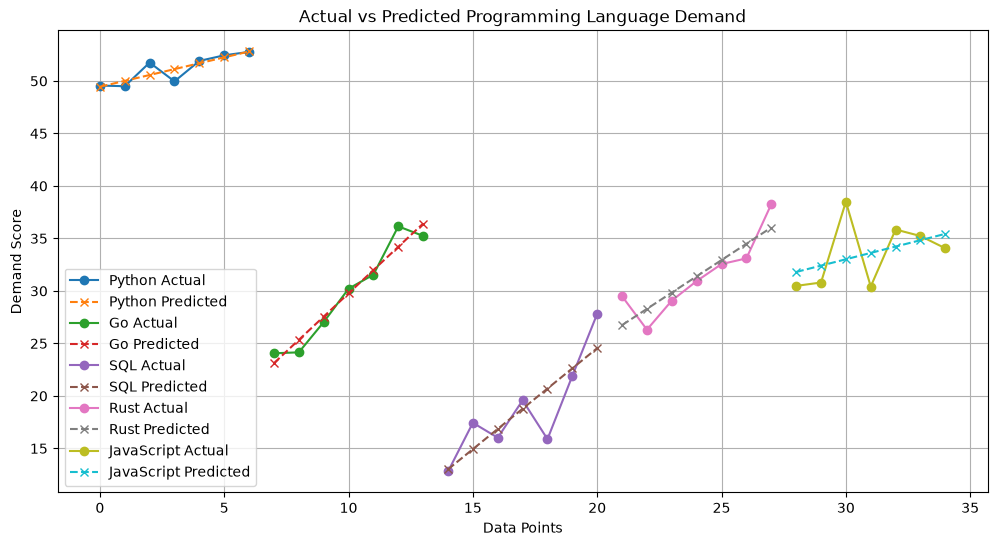

In [46]:
plt.figure(figsize=(12, 6))

for language in languages:

    temp = actual_vs_predicted[
        actual_vs_predicted["language"] == language
    ]

    plt.plot(
        temp.index,
        temp["actual_demand"],
        marker="o",
        label=f"{language} Actual"
    )

    plt.plot(
        temp.index,
        temp["predicted_demand"],
        linestyle="--",
        marker="x",
        label=f"{language} Predicted"
    )

plt.title("Actual vs Predicted Programming Language Demand")
plt.xlabel("Data Points")
plt.ylabel("Demand Score")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
comparison_df = df[["year", "language", "demand_score"]].copy()

comparison_df["predicted_demand"] = comparison_df["year"].apply(
    lambda year: 0
)

comparison_df.head()

,year,language,demand_score,predicted_demand
0,2020,Python,49.56,0
1,2020,JavaScript,30.48,0
2,2020,Java,28.98,0
3,2020,SQL,12.80,0
4,2020,C++,18.78,0


In [48]:
from sklearn.metrics import mean_absolute_error

language_errors = []

for language in languages:

    temp = comparison_df[
        comparison_df["language"] == language
    ]

    mae = mean_absolute_error(
        temp["demand_score"],
        temp["predicted_demand"]
    )

    language_errors.append({
        "language": language,
        "MAE": mae
    })

language_errors = pd.DataFrame(language_errors)

language_errors.sort_values("MAE")

,language,MAE
2,SQL,18.778571
1,Go,29.770000
3,Rust,31.391429
4,JavaScript,33.620000
0,Python,51.127143


In [49]:
actual_vs_predicted[
    actual_vs_predicted["language"] == "Python"
][[
    "year",
    "language",
    "actual_demand",
    "predicted_demand"
]]

,year,language,actual_demand,predicted_demand
0,2036,Python,49.56,49.448214
1,2036,Python,49.50,50.007857
2,2036,Python,51.75,50.567500
3,2036,Python,49.96,51.127143
4,2036,Python,51.91,51.686786
5,2036,Python,52.44,52.246429
6,2036,Python,52.77,52.806071


In [50]:
actual_vs_predicted = []

for language in languages:

    temp = df[df["language"] == language]

    X = temp[["year"]]
    y = temp["demand_score"]

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    for year, actual, predicted in zip(
        temp["year"], y, predictions
    ):
        actual_vs_predicted.append({
            "year": year,
            "language": language,
            "actual_demand": actual,
            "predicted_demand": predicted
        })

actual_vs_predicted = pd.DataFrame(actual_vs_predicted)

actual_vs_predicted.head(10)

,year,language,actual_demand,predicted_demand
0,2020,Python,49.56,49.448214
1,2021,Python,49.50,50.007857
2,2022,Python,51.75,50.567500
3,2023,Python,49.96,51.127143
4,2024,Python,51.91,51.686786
5,2025,Python,52.44,52.246429
6,2026,Python,52.77,52.806071
7,2020,Go,24.06,23.120714
8,2021,Go,24.15,25.337143
9,2022,Go,27.03,27.553571


In [51]:
from sklearn.metrics import mean_absolute_error

language_errors = []

for language in languages:

    temp = actual_vs_predicted[
        actual_vs_predicted["language"] == language
    ]

    mae = mean_absolute_error(
        temp["actual_demand"],
        temp["predicted_demand"]
    )

    language_errors.append({
        "language": language,
        "MAE": mae
    })

language_errors = pd.DataFrame(language_errors)

language_errors.sort_values("MAE")

,language,MAE
0,Python,0.488878
1,Go,0.950408
3,Rust,1.419184
2,SQL,1.880204
4,JavaScript,2.145510


🟢 Best model fit → Python (lowest MAE)
🟠 Highest predicted growth → Go (66.24%)

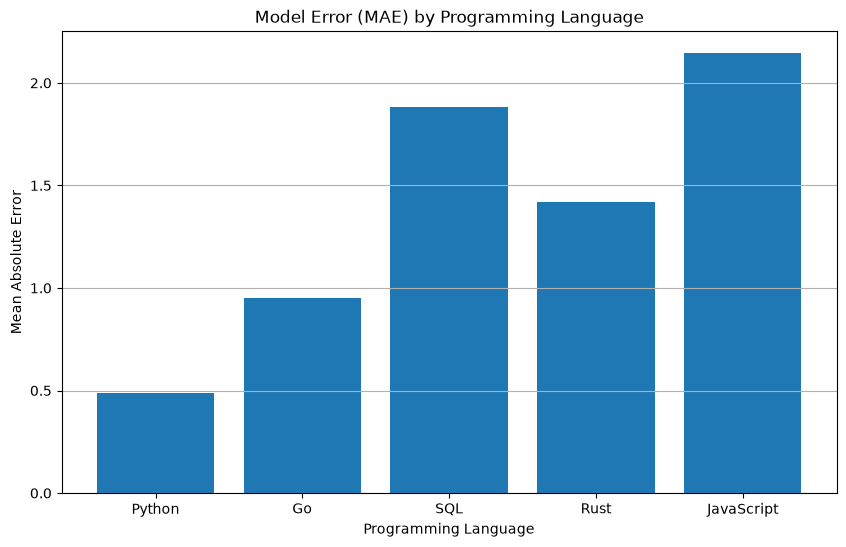

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    language_errors["language"],
    language_errors["MAE"]
)

plt.title("Model Error (MAE) by Programming Language")
plt.xlabel("Programming Language")
plt.ylabel("Mean Absolute Error")

plt.grid(axis="y")
plt.show()

In [53]:
from sklearn.metrics import r2_score

language_r2 = []

for language in languages:

    temp = actual_vs_predicted[
        actual_vs_predicted["language"] == language
    ]

    r2 = r2_score(
        temp["actual_demand"],
        temp["predicted_demand"]
    )

    language_r2.append({
        "language": language,
        "R2": r2
    })

language_r2 = pd.DataFrame(language_r2)

language_r2.sort_values("R2", ascending=False)

,language,R2
1,Go,0.944181
3,Rust,0.777108
0,Python,0.737614
2,SQL,0.710869
4,JavaScript,0.172089


Highest current demand: Python

Fastest predicted growth: Go

Lowest MAE: Python

Highest R²: Go

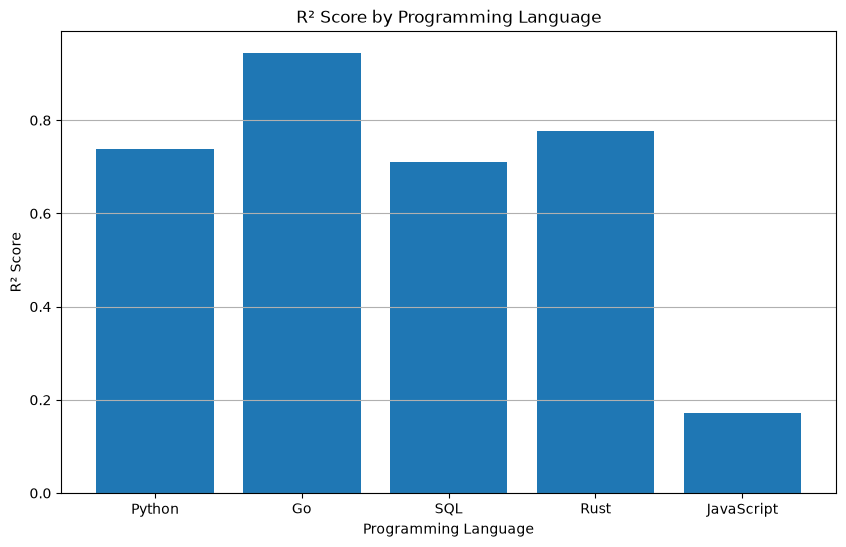

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    language_r2["language"],
    language_r2["R2"]
)

plt.title("R² Score by Programming Language")
plt.xlabel("Programming Language")
plt.ylabel("R² Score")

plt.grid(axis="y")
plt.show()

In [55]:
final_analysis = growth_df.merge(
    language_errors,
    on="language"
)

final_analysis = final_analysis.merge(
    language_r2,
    on="language"
)

final_analysis = final_analysis.sort_values(
    "growth_percent",
    ascending=False
)

final_analysis

,language,demand_2026,demand_2036,growth_percent,absolute_growth,MAE,R2
3,Go,35.24,58.583571,66.241690,23.343571,0.950408,0.944181
2,SQL,27.82,43.785000,57.386772,15.965000,1.880204,0.710869
4,Rust,38.26,51.527500,34.677209,13.267500,1.419184,0.777108
1,JavaScript,34.06,41.489643,21.813397,7.429643,2.145510,0.172089
0,Python,52.77,58.402500,10.673678,5.632500,0.488878,0.737614


Based on the historical programming language demand data from 2020 to 2026, a Linear Regression model was used to forecast demand from 2027 to 2036.

Python had the highest demand score in 2026. However, according to the model's forecast, Go showed the highest predicted growth rate of approximately 66.24% and reached the highest predicted demand score in 2036.

SQL showed the second-highest predicted growth rate, followed by Rust. Python showed comparatively lower growth because its demand was already high in the initial data.

Model evaluation showed that Python had the lowest Mean Absolute Error (MAE), indicating that its predictions were closest to the actual historical values. Go achieved the highest R² score of approximately 0.94, indicating a strong fit between the model and Go's historical demand trend.

Therefore, based on this Linear Regression model and the available historical data, Go appears to have the strongest predicted future growth among the programming languages analyzed.

🧠 Is conclusion ka simple meaning

Python → 2026 mein highest demand

Go → fastest predicted growth 🚀

SQL → second fastest growth

Python MAE lowest → Python predictions historical data ke closest

Go R² highest → Go ka trend model ne best explain kiya

⚠️ Project Limitations

1.The dataset contains a limited number of historical years (2020–2026).

2. Linear Regression assumes that the trend will continue in a linear pattern, which may not always happen in the real world.

3. Programming language demand can be affected by new technologies, AI development, industry requirements, economic conditions, and developer preferences.

4. Therefore, the 2036 predictions should be considered estimates based on historical trends rather than guaranteed future results.

🚀 Future Improvements

1. Use a larger dataset with more historical years.

2. Include additional factors such as job postings, GitHub activity, developer surveys, and industry trends.

3. Experiment with more advanced forecasting models.

4. Use time-series forecasting techniques such as ARIMA or Prophet.

5. Regularly update the model with new data to improve future predictions.